# PART A: DATASET PREPARATION AND TEXT PREPROCESSING

The Keras IMDB dataset is already integer encoded. We load it, inspect the class distribution, create a validation split, and apply sequence padding.


In [ ]:
# EXPERIMENT NO. 6 - PART A
# Roll No: 24BAD407

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

print("TensorFlow Version:", tf.__version__)


I0000 00:00:1790589236.572159   25424 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790589236.572867   25424 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1790589236.619777   25424 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790589238.109644   25424 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

TensorFlow Version: 2.22.0-rc0


In [4]:
# Load IMDB dataset

vocab_size = 10000
max_length = 200

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

print("Training samples:", len(x_train))
print("Testing samples:", len(x_test))

print("\nTraining Positive Reviews:", np.sum(y_train == 1))
print("Training Negative Reviews:", np.sum(y_train == 0))
print("Testing Positive Reviews:", np.sum(y_test == 1))
print("Testing Negative Reviews:", np.sum(y_test == 0))


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Training samples: 25000
Testing samples: 25000

Training Positive Reviews: 12500
Training Negative Reviews: 12500
Testing Positive Reviews: 12500
Testing Negative Reviews: 12500


In [5]:
# Sequence padding

x_train = pad_sequences(
    x_train,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

x_test = pad_sequences(
    x_test,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

print("Training shape after padding:", x_train.shape)
print("Testing shape after padding:", x_test.shape)


Training shape after padding: (25000, 200)
Testing shape after padding: (25000, 200)


In [6]:
# Create validation set

x_train, x_val, y_train, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Final Dataset Shapes")
print("Training   :", x_train.shape)
print("Validation :", x_val.shape)
print("Testing    :", x_test.shape)

print("\nSample numerical sequence:")
print(x_train[0][:30])

print("\nSample label:", "Positive" if y_train[0] == 1 else "Negative")


Final Dataset Shapes
Training   : (20000, 200)
Validation : (5000, 200)
Testing    : (25000, 200)

Sample numerical sequence:
[   1  806    8  135   13   28   57  326   51  363    9  399  252  202
  178  102   40 1354  778  449   34    4   96  363   13  104   36  203
 1108    4]

Sample label: Positive


# PART B: EMBEDDING GENERATION

The Embedding layer maps every integer token to a dense vector. In this experiment, each token is represented by a 64-dimensional vector.


In [ ]:
# EXPERIMENT NO. 6 - PART B
# Roll No: 24BAD407

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding

embedding_dim = 64

embedding_model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim
    )
])

sample_input = x_train[:1]
embedding_output = embedding_model(sample_input)

print("Input Shape:", sample_input.shape)
print("Embedding Shape:", embedding_output.shape)
print("Embedding Dimension:", embedding_dim)

print("\nFirst 5 embedding vectors:")
print(embedding_output[0][:5].numpy())


E0000 00:00:1790589249.776482   25424 cuda_executor.cc:1690] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
=== Source Location Trace: === 
external/xla/xla/stream_executor/cuda/cuda_status.cc:68

W0000 00:00:1790589249.777175   28112 cuda_executor.cc:1710] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
=== Source Location Trace: === 
external/xla/xla/stream_executor/cuda/cudnn_api_wrappers.cc:77
external/xla/xla/stream_executor/cuda/cudnn_api_wrappers.cc:107
external/xla/xla/stream_executor/cuda/cudnn_api_wrappers.cc:112

W0000 00:00:1790589249.795688   25424 dlopen_checker.cc:38] Could not load dynamic library 'libcudart.so.12'; dlerror: libcudart.so.12: cannot open shared object file: No such file or directory
W0000 00:00:1790589249.795738   25

Input Shape: (1, 200)
Embedding Shape: (1, 200, 64)
Embedding Dimension: 64

First 5 embedding vectors:
[[-1.57421008e-02 -3.60164866e-02  1.75878443e-02  2.79486179e-03
  -2.13483460e-02 -4.60447669e-02 -1.04146004e-02  4.06813286e-02
   1.76724307e-02 -3.19749117e-02  2.25873925e-02  3.02824639e-02
  -3.96763906e-02 -3.69295366e-02  4.90342714e-02  1.01530440e-02
  -4.22878377e-02  4.59914319e-02  3.94280814e-02 -3.63517404e-02
   2.25864165e-02  5.69159910e-03  4.87190373e-02  4.20505516e-02
   2.23873369e-02  3.18296887e-02  1.45167112e-03  3.13565172e-02
  -2.77628433e-02 -1.67167895e-02  2.11294182e-02 -2.38163006e-02
   2.93506868e-02 -3.16457525e-02  6.47295639e-03 -2.61147972e-02
   4.88698743e-02  1.89799778e-02  4.07369398e-02 -4.11592834e-02
   3.52580883e-02  4.66341414e-02  3.37713696e-02 -2.43932139e-02
   2.72682048e-02 -3.42486724e-02 -3.29021439e-02  9.45271179e-03
   2.26658694e-02 -1.14420801e-03 -3.03656105e-02  5.31310961e-03
  -2.24472880e-02 -2.02374216e-02 -3.4

# PART C: IMPLEMENTING THE LSTM MODEL

### Architecture

Input Sequence → Embedding → LSTM → Dropout → Dense/Sigmoid → Sentiment


In [ ]:
# EXPERIMENT NO. 6 - PART C
# Roll No: 24BAD407

from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim
    ),
    LSTM(64),
    Dropout(0.5),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# PART D: MODEL TRAINING AND SENTIMENT PREDICTION


In [9]:
# Train the LSTM model

epochs = 5
batch_size = 128

history = model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    verbose=1
)


Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 53s 326ms/step - accuracy: 0.5088 - loss: 0.6933 - val_accuracy: 0.5046 - val_loss: 0.6916
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 49s 309ms/step - accuracy: 0.5644 - loss: 0.6828 - val_accuracy: 0.6234 - val_loss: 0.6623
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 48s 306ms/step - accuracy: 0.6380 - loss: 0.6476 - val_accuracy: 0.6678 - val_loss: 0.6212
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 48s 306ms/step - accuracy: 0.6571 - loss: 0.5989 - val_accuracy: 0.6362 - val_loss: 0.6193
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 47s 302ms/step - accuracy: 0.7293 - loss: 0.5502 - val_accuracy: 0.5526 - val_loss: 0.7820


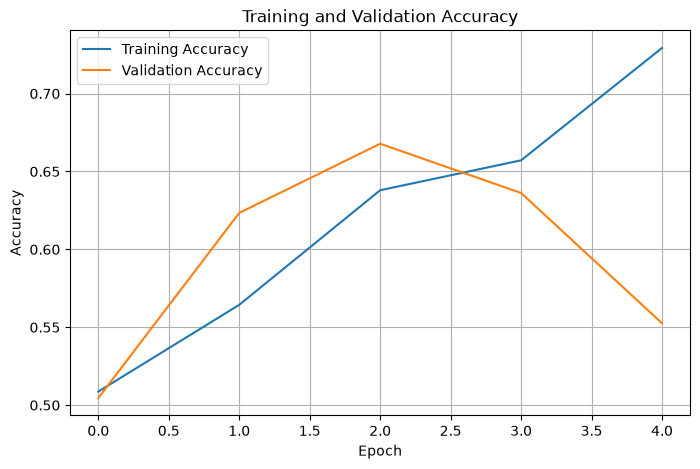

In [10]:
# Accuracy vs Epoch

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


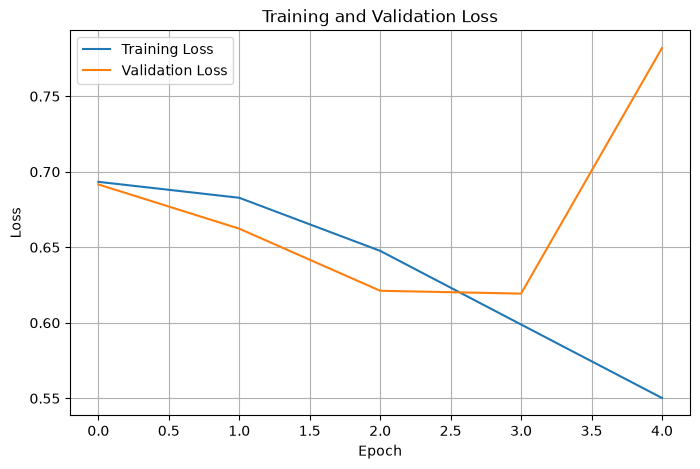

In [11]:
# Loss vs Epoch

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


In [12]:
# Evaluate model on test dataset

test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)


Test Loss: 0.7863253951072693
Test Accuracy: 0.5501999855041504


In [13]:
# Accuracy, Precision, Recall, F1-score and Confusion Matrix

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

y_probability = model.predict(x_test, verbose=0)
y_pred = (y_probability >= 0.5).astype(int).flatten()

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Negative", "Positive"]
    )
)

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)


Accuracy : 0.5502
Precision: 0.5282797782685115
Recall   : 0.93776
F1 Score : 0.6758338378160224

Classification Report:
              precision    recall  f1-score   support

    Negative       0.72      0.16      0.27     12500
    Positive       0.53      0.94      0.68     12500

    accuracy                           0.55     25000
   macro avg       0.63      0.55      0.47     25000
weighted avg       0.63      0.55      0.47     25000

Confusion Matrix:
[[ 2033 10467]
 [  778 11722]]


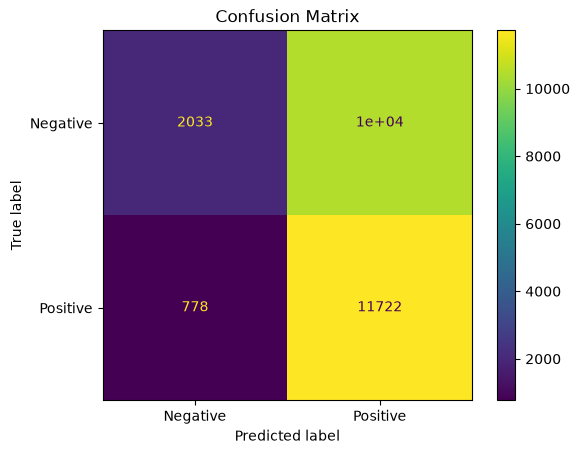

In [14]:
# Display confusion matrix

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
).plot()

plt.title("Confusion Matrix")
plt.show()


In [15]:
# Custom sentiment prediction using IMDB vocabulary

word_index = imdb.get_word_index()

def encode_review(text):
    words = text.lower().split()
    sequence = [1]  # START token

    for word in words:
        index = word_index.get(word, 2) + 3

        if index >= vocab_size:
            index = 2

        sequence.append(index)

    return pad_sequences(
        [sequence],
        maxlen=max_length,
        padding="post",
        truncating="post"
    )

def predict_sentiment(text):
    sequence = encode_review(text)
    probability = float(model.predict(sequence, verbose=0)[0][0])
    sentiment = "Positive" if probability >= 0.5 else "Negative"

    print("\nReview:", text)
    print("Probability:", probability)
    print("Predicted Sentiment:", sentiment)

predict_sentiment("This movie was excellent and I really enjoyed it")
predict_sentiment("This movie was boring and disappointing")


1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

Review: This movie was excellent and I really enjoyed it
Probability: 0.7971450090408325
Predicted Sentiment: Positive

Review: This movie was boring and disappointing
Probability: 0.7971429228782654
Predicted Sentiment: Positive
